In [1]:
import numpy as np
from gpcam import GPOptimizer

import random

import pandas as pd

import matplotlib.pyplot as plt

import plotly.graph_objects as go
import networkx as nx

import os

from scipy.spatial.distance import cdist

import time

import warnings
# Add this at the top of your code or before running experiments
warnings.filterwarnings("ignore", message="No noise function or measurement noise provided.*")

# Using Data Extracted from the Geometric environment

In [ ]:
# Load everything
all_geodesic_distances = np.load('Data/teddy_exact_geodesic_distances_graph.npy') # ('teddy_geodesic_distances.npy')
vertices = np.load('Data/teddy_vertices.npy')
faces = np.load('Data/teddy_faces.npy')
y_values = np.load('Data/teddy_y_values.npy')

print("Done")

Done


In [ ]:

# Create mesh plot with y-values as colors
fig = go.Figure(data=[
    go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        intensity=y_values,  # Color by y-values
        colorscale='plasma',  # Or 'RdBu', 'Plasma', etc.
        colorbar=dict(title="Y value"),
        showscale=True
    )
])

# Clean up the figure (using your update_figure function)
fig.update_layout(scene_aspectmode="auto")
fig.update_scenes(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))
fig.update_layout(
    scene_camera=dict(
        up=dict(x=0, y=1, z=0),
        center=dict(x=0, y=0, z=0),
        eye=dict(x=0, y=0.9, z=1.8)   # zoom out: increase from 0.7/1.25
    )
)

fig.show()

In [4]:
def plot_geodesic(source, target, vertices, faces, y_values, mesh_graph, opacity=0.85):
    """
    Plot the geodesic path between two vertices on the teddy mesh.

    Parameters
    ----------
    source     : int   — start vertex index
    target     : int   — end vertex index
    vertices   : np.ndarray (n, 3)
    faces      : np.ndarray (f, 3)
    y_values   : np.ndarray (n,)
    mesh_graph : nx.Graph  — prebuilt weighted mesh graph
    opacity    : float     — mesh transparency (default 0.85)

    Returns
    -------
    fig : plotly Figure
    """
    # Validate indices
    n = len(vertices)
    assert 0 <= source < n, f"source {source} out of range [0, {n-1}]"
    assert 0 <= target < n, f"target {target} out of range [0, {n-1}]"

    # Geodesic path
    path_vertices = nx.shortest_path(mesh_graph, source=source, target=target, weight='weight')
    path_coords   = vertices[path_vertices]
    path_length   = sum(
        np.linalg.norm(vertices[path_vertices[i+1]] - vertices[path_vertices[i]])
        for i in range(len(path_vertices) - 1)
    )

    print(f"Geodesic: vertex {source} → vertex {target}")
    print(f"  Hops:   {len(path_vertices) - 1}")
    print(f"  Length: {path_length:.4f}")

    # Build figure
    fig = go.Figure()

    # Mesh
    fig.add_trace(go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        intensity=y_values,
        colorscale='Viridis',
        colorbar=dict(title="Y value"),
        showscale=True,
        opacity=opacity,
    ))

    # Geodesic line
    fig.add_trace(go.Scatter3d(
        x=path_coords[:, 0],
        y=path_coords[:, 1],
        z=path_coords[:, 2],
        mode='lines',
        line=dict(color='red', width=6),
        name=f'Geodesic (len={path_length:.2f})',
    ))

    # Start point
    fig.add_trace(go.Scatter3d(
        x=[vertices[source, 0]],
        y=[vertices[source, 1]],
        z=[vertices[source, 2]],
        mode='markers+text',
        marker=dict(color='lime', size=8),
        text=[f'Start ({source})'],
        textposition='top center',
        name='Start',
    ))

    # End point
    fig.add_trace(go.Scatter3d(
        x=[vertices[target, 0]],
        y=[vertices[target, 1]],
        z=[vertices[target, 2]],
        mode='markers+text',
        marker=dict(color='yellow', size=8),
        text=[f'End ({target})'],
        textposition='top center',
        name='End',
    ))

    fig.update_layout(scene_aspectmode="auto")
    fig.update_scenes(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False)
    fig.update_layout(
        margin=dict(l=0, r=0, t=40, b=0),
        title=f"Geodesic: vertex {source} → {target}  |  length={path_length:.3f}  |  hops={len(path_vertices)-1}",
        scene_camera=dict(
            up=dict(x=0, y=1, z=0),
            center=dict(x=0, y=0, z=0),
            eye=dict(x=0, y=0.7, z=1.25)
        )
    )

    return fig

# ============================================================================
# 2. BUILD MESH GRAPH
# ============================================================================
def build_mesh_graph(vertices, faces):
    G = nx.Graph()
    G.add_nodes_from(range(len(vertices)))
    for face in faces:
        face = list(face)
        n = len(face)
        for k in range(n):
            u = face[k]
            v = face[(k + 1) % n]
            if u != v and not G.has_edge(u, v):
                weight = float(np.linalg.norm(vertices[u] - vertices[v]))
                G.add_edge(u, v, weight=weight)
    return G

print("🔧 Constructing mesh graph...")
mesh_graph = build_mesh_graph(vertices, faces)
print("Mesh graph built")

🔧 Constructing mesh graph...
Mesh graph built


In [5]:
fig = plot_geodesic(1000, 1400, vertices, faces, y_values, mesh_graph)
fig.show()

Geodesic: vertex 1000 → vertex 1400
  Hops:   16
  Length: 32.7202


# Running One GP model training

In [20]:
# Step 1: First sample the subset of points
np.random.seed(12345) # 3256)

# Step 3: Now split the subset into train and test
n_train = 600# 1500 # 50
n_test = 50

# Sample ALL indices at once, then split
indices_all = np.random.choice(len(vertices), size=n_train + n_test, replace=False)

# Split into train and test
indices_train = indices_all[:n_train]
indices_test = indices_all[n_train:]

# Extract data
#x_train = vertices[indices_train,:]
x_train = indices_train.reshape(-1,1)
y_train = y_values[indices_train]

# x_test = vertices[indices_test,:]
x_test = indices_test.reshape(-1,1)
y_test = y_values[indices_test]

print(f"Training points: {len(indices_train)}")
print(f"Test points: {len(indices_test)}")

indices_train_sort = np.sort(indices_train)


Training points: 600
Test points: 50


In [21]:
# Step 2 (Fixed): Define the basic GP components
def matern_kernel_diff2(distance, length):
    """
    Function for the Matern kernel, order of differentiability = 2.
    kernel = (
        1.0
        + ((np.sqrt(5.0) * distance) / (length))
        + ((5.0 * distance ** 2) / (3.0 * length ** 2))
    ) * np.exp(-(np.sqrt(5.0) * distance) / length)

    Parameters
    ----------
    distance : scalar or np.ndarray
        Distance between a set of points.
    length : scalar
        The length scale hyperparameters.

    Return
    ------
    Kernel output : same as distance parameter.
    """

    kernel = (1.0
                 + ((np.sqrt(5.0) * distance) / (length))
                 + ((5.0 * distance ** 2) / (3.0 * length ** 2))
             ) * np.exp(-(np.sqrt(5.0) * distance) / length)
    return kernel



def bump(d, r, beta, ampl):
    """
    Bump function for the kernel
    d: distances (can be any shape)
    r: radius parameter. Identifies the cutoff after which the covariance becomes 0 when beta=0
    beta: shape parameter. 0 results in a square-like function, larger values cause faster decay
    ampl: amplitude
    """
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values

def bump_k(x1, x2, hps):

    # x1 and x2 ARE the indices - just extract them
    x1_idx = x1.astype(int).flatten()
    x2_idx = x2.astype(int).flatten()
    
    # Extract geodesic distances
    # d1: distances from x1 points to training points
    # We want shape: (len(x1), n_train) - each row is one x1 point's distances to all training points
    d1 = all_geodesic_distances[np.ix_(x1_idx, indices_train)]  # Shape: (len(x1), n_train)
    d2 = all_geodesic_distances[np.ix_(x2_idx, indices_train)]  # Shape: (len(x2), n_train)
    
    # Apply bump to create embedding
    # phi_x1[i, :] = embedding of x1[i] based on distances to all training points
    phi_x1 = bump(d1, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x1), n_train)
    phi_x2 = bump(d2, hps[1], beta=1, ampl=hps[2])  # Shape: (len(x2), n_train)
    
    # Matern on embeddings
    D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))

    #return hps[0] * np.exp(-D_mat**2 / hps[3]) #, D_mat
    
    return hps[0] * matern_kernel_diff2(D_mat, hps[3])
    

def my_noise(x, hps):
    s = np.ones(len(x)) * hps[4]
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0 # hps[4]
    return m

In [ ]:
# 1. Signal variance (hps[0]): [0.01 * y_var, 10 * y_var]
y_var = np.var(y_train)

# 2. Bump radius (hps[1]): [min distance, maximum distance]
train_geodesic = all_geodesic_distances[np.ix_(x_train.flatten(), x_train.flatten())]
non_zero_dists = train_geodesic[train_geodesic > 0]

# Define hyperparameter bounds
bounds = np.empty((5, 2))
bounds[0] = np.array([1e2, 1e6])   # 1e6                                     # sigma_f: signal variance      
bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # bump radius
bounds[2] = np.array([1e-1,50])                                              # bump amplitude
bounds[3] = np.array([1e-3, 50])                                             # Exponential lengthscale
#bounds[4] = np.array([1e-5, 1])                                             # bump beta
bounds[4] = np.array([1e-6, 10])                                             # Noise variance

print(f"\nHyperparameter bounds:")
print(f"  Signal variance: [{bounds[0, 0]:.6f}, {bounds[0, 1]:.6f}]")
print(f"  Bump radius:     [{bounds[1, 0]:.6f}, {bounds[1, 1]:.6f}]")
print(f"  Bump Amplitude:  [{bounds[2, 0]:.6f}, {bounds[2, 1]:.6f}]")
print(f"  RBF length:      [{bounds[3, 0]:.6f}, {bounds[3, 1]:.6f}]")
print(f"  Noise Variance:  [{bounds[4, 0]:.6f}, {bounds[4, 1]:.6f}]")


Hyperparameter bounds:
  Signal variance: [100.000000, 1000000.000000]
  Bump radius:     [0.037353, 55.819336]
  Bump Amplitude:  [0.100000, 50.000000]
  RBF length:      [0.001000, 50.000000]
  Noise Variance:  [0.000001, 10.000000]


In [ ]:
# Step 4: Configure hyperparameters and initialize GPOptimizer

# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)

trained_hps = np.array([1.47842468e+04, 1.87316382e+01, 8.68944986e+00, 4.81137217e+01, 2.75896743e-05])

print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(x_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=bump_k,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")

# # Step 5: Train the GP model
my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='global')#, max_iter=15000)

# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")


Initial hyperparameters: [5.00050000e+05 2.79283445e+01 2.50500000e+01 2.50005000e+01
 5.00000050e+00]
Initial log likelihood: -4229.776822
Final hyperparameters:   [1.38194461e+04 2.84664119e+01 1.22510916e+01 4.06885967e+01
 5.20507467e-04]
Final log likelihood:    -2677.11


'\nInitial hyperparameters: [5.00050000e+05 2.84041982e+01 2.50500000e+01 2.50005000e+01\n 5.00000050e+00]\nInitial log likelihood: -2110.807932\nFinal hyperparameters:   [6.24077245e+03 3.05100554e+01 2.25690528e+01 3.55025313e+01\n 1.31909429e-02]\nFinal log likelihood:    -1485.12\n\n'

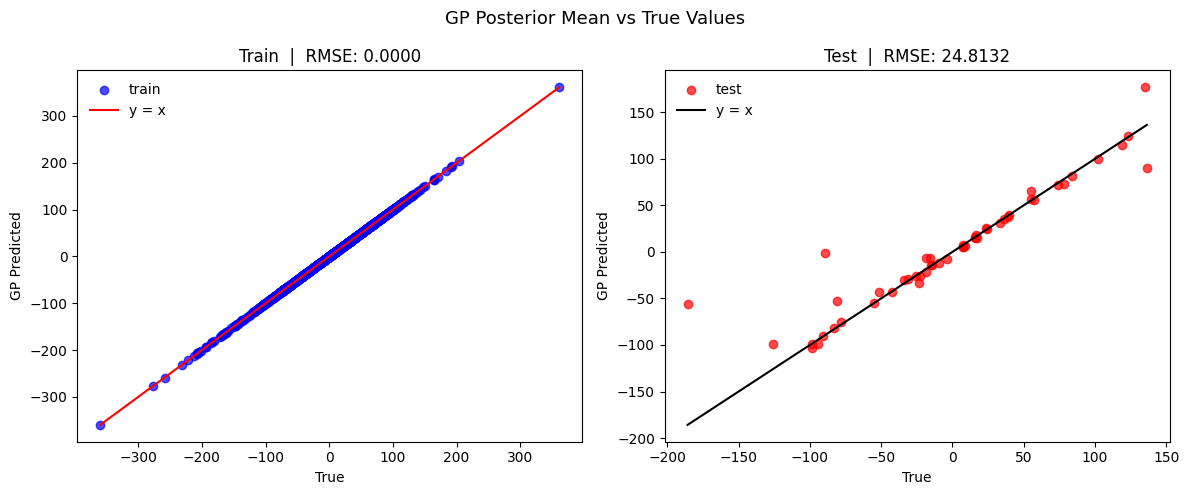

Train RMSE: 0.0000
Test  RMSE: 24.8132


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Train ──────────────────────────────────────────────────────────────
f_train = my_gpo.posterior_mean(x_train)["m(x)"]
rmse_train = my_gpo.rmse(x_train, y_train)

my_line_train = np.linspace(np.min(y_train), np.max(y_train), 10)

axes[0].scatter(y_train, f_train, color="blue", label="train", alpha=0.7)
axes[0].plot(my_line_train, my_line_train, c="red", label="y = x")
axes[0].set_xlabel("True")
axes[0].set_ylabel("GP Predicted")
axes[0].set_title(f"Train  |  RMSE: {rmse_train:.4f}")
axes[0].legend(frameon=False)

# ── Right: Test ───────────────────────────────────────────────────────────────
f_test = my_gpo.posterior_mean(x_test)["m(x)"]
rmse_test = my_gpo.rmse(x_test, y_test)

my_line_test = np.linspace(np.min(y_test), np.max(y_test), 10)

axes[1].scatter(y_test, f_test, color="red", label="test", alpha=0.7)
axes[1].plot(my_line_test, my_line_test, c="black", label="y = x")
axes[1].set_xlabel("True")
axes[1].set_ylabel("GP Predicted")
axes[1].set_title(f"Test  |  RMSE: {rmse_test:.4f}")
axes[1].legend(frameon=False)

plt.suptitle("GP Posterior Mean vs True Values", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test  RMSE: {rmse_test:.4f}")

In [28]:
crps_test = my_gpo.crps(x_test, y_test)
print(crps_test)

from scipy.stats import norm

def picp(my_gpo, x_test, y_true, interval=0.95):
        mu = my_gpo.posterior_mean(x_test)["m(x)"]
        sigma = np.sqrt(my_gpo.posterior_covariance(x_test, add_noise=True)["v(x)"])

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp
    
picp_test = picp(my_gpo, x_test, y_test)
print(picp_test)


(np.float64(7.661920978401794), np.float64(17.943061658230093))
0.94


# Scanning the radius

In [1]:
import json
from tqdm import tqdm

import numpy as np
from gpcam import GPOptimizer

import random

import pandas as pd

import matplotlib.pyplot as plt

import plotly.graph_objects as go

import os

from scipy.spatial.distance import cdist
from scipy.stats import norm

import time

import warnings
# Add this at the top of your code or before running experiments
warnings.filterwarnings("ignore", message="No noise function or measurement noise provided.*")

In [ ]:
# Load everything
all_geodesic_distances = np.load('Data/teddy_exact_geodesic_distances_graph.npy')
vertices = np.load('Data/teddy_vertices.npy')
faces = np.load('Data/teddy_faces.npy')
y_values = np.load('Data/teddy_y_values.npy')

print("Done")

Done


In [3]:
# def generate_training_configurations():
#     # Configuration
#     training_sizes = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 800]
#     n_trials = 100
#     total_data_points = 1598 #len(vertices)
    
#     # Generate 100 random seeds
#     np.random.seed(42)
#     random_seeds = np.random.randint(1, 100000, size=n_trials)
    
#     # Generate single test set FIRST
#     np.random.seed(9999)
#     test_indices = np.random.choice(total_data_points, size=500, replace=False).tolist()
#     test_indices_set = set(test_indices)  # For fast lookup
    
#     # Create pool of available training indices (exclude test set)
#     available_train_indices = [i for i in range(total_data_points) if i not in test_indices_set]
    
#     # Structure to store all configurations
#     training_configs = {
#         "test_indices": test_indices,
#         "training_configurations": {}
#     }
    
#     print(f"Generating configurations for {len(training_sizes)} training sizes...")
#     print(f"Each size will have {n_trials} trials")
#     print(f"Available training pool: {len(available_train_indices)} (after excluding {len(test_indices)} test samples)")
    
#     for train_size in tqdm(training_sizes, desc="Training sizes"):
#         train_size_configs = []
        
#         for trial_idx in tqdm(range(n_trials), desc=f"Size {train_size}", leave=False):
#             seed = int(random_seeds[trial_idx])
            
#             # Set seed and generate indices
#             np.random.seed(seed)
#             random.seed(seed)
            
#             # Sample from AVAILABLE indices only (excluding test set)
#             indices_train = random.sample(available_train_indices, train_size)
            
#             # Store configuration for this trial
#             trial_config = {
#                 "seed": seed,
#                 "indices_train": indices_train
#             }
            
#             train_size_configs.append(trial_config)
        
#         # Store all trials for this training size
#         training_configs["training_configurations"][str(train_size)] = train_size_configs
    
#     return training_configs

# # Generate the configurations
# print("Generating training configurations...")
# training_configs = generate_training_configurations()

# # Save to JSON file
# with open('teddy_example_training_configurations.json', 'w') as f:
#     json.dump(training_configs, f, indent=2)

# print(f"✅ Saved training configurations to 'training_configurations.json'")
# print(f"📊 Test indices: {len(training_configs['test_indices'])}")
# print(f"📊 Training sizes: {len(training_configs['training_configurations'])}")
# print(f"🎯 Total trials: {sum(len(trials) for trials in training_configs['training_configurations'].values())}")

In [5]:
# 2. Bump radius (hps[1]): [min distance, maximum distance]
non_zero_dists = all_geodesic_distances[all_geodesic_distances > 0]
radius_values = np.linspace(np.min(non_zero_dists), np.max(non_zero_dists), 25)  
radius_values

array([3.8354921e-03, 2.3755717e+00, 4.7473083e+00, 7.1190443e+00,
       9.4907808e+00, 1.1862517e+01, 1.4234253e+01, 1.6605989e+01,
       1.8977726e+01, 2.1349463e+01, 2.3721199e+01, 2.6092936e+01,
       2.8464670e+01, 3.0836407e+01, 3.3208141e+01, 3.5579880e+01,
       3.7951614e+01, 4.0323349e+01, 4.2695087e+01, 4.5066822e+01,
       4.7438560e+01, 4.9810295e+01, 5.2182034e+01, 5.4553768e+01,
       5.6925507e+01], dtype=float32)

In [ ]:
def my_noise(x, hps):
    s = np.ones(len(x)) * hps[3]  # noise variance (last of 4 hps now)
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0
    return m

def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def load_or_create_results_file(filename='gp_experiment_results.json'):
    """Load existing results or create new file"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            try:
                existing_results = json.load(f)
                print(f"📂 Loaded {len(existing_results)} existing results")
                return existing_results
            except:
                print("🆕 Creating new results file")
                return []
    else:
        print("🆕 Creating new results file")
        return []

def get_test_data(configs, vertices, ground_truth):
    """Get the fixed test data"""
    test_indices = configs['test_indices']
    x_test = np.array(test_indices).reshape(-1,1)
    y_test = ground_truth[test_indices]
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, vertices, ground_truth):
    """Get training data for specific configuration"""
    trial = configs['training_configurations'][str(training_size)][trial_number]
    seed = trial['seed']
    indices_train = trial['indices_train']
    
    x_train = np.array(indices_train).reshape(-1,1)
    y_train = ground_truth[indices_train]
    
    return x_train, y_train, seed, indices_train

def get_hps_bounds():
    """
    Bounds for the 4 hyperparameters that are actually being optimized.
    (Bump radius is now fixed externally and is NOT part of the optimized hps.)
    """
    bounds = np.empty((4, 2))
    bounds[0] = np.array([1e2, 1e6])     # sigma_f: signal variance
    bounds[1] = np.array([1e-1, 10])     # bump amplitude
    bounds[2] = np.array([1e-3, 40])     # Exponential/Matern lengthscale
    bounds[3] = np.array([1e-6, 10])     # Noise variance
    return bounds

def matern_kernel_diff2(distance, length):
    kernel = (1.0
                 + ((np.sqrt(5.0) * distance) / (length))
                 + ((5.0 * distance ** 2) / (3.0 * length ** 2))
             ) * np.exp(-(np.sqrt(5.0) * distance) / length)
    return kernel

def train_gp_model(x_train, y_train, bounds, radius):
    """Train GP model with a FIXED bump radius (not optimized)."""
    
    # Initial hyperparameters (middle of bounds) -- now length 4
    init_hps = np.mean(bounds, axis=1)

    def bump(d, r, beta, ampl):
        a = 1.0 - (d**2 / r**2)
        bump_values = np.zeros_like(a)
        
        positive_mask = a > 0.0
        if np.any(positive_mask):
            e = np.exp((-beta / a[positive_mask]) + beta)
            bump_values[positive_mask] = ampl * e
        
        return bump_values
    
    def bump_k_multiple_trials(x1, x2, hps):
        # hps = [sigma_f, bump_amplitude, lengthscale, noise_var]
        # radius is captured from the enclosing scope (fixed, not trained)
        
        x1_idx = x1.astype(int).flatten()
        x2_idx = x2.astype(int).flatten()
        
        d1 = all_geodesic_distances[np.ix_(x1_idx, indices_train_trials)]
        d2 = all_geodesic_distances[np.ix_(x2_idx, indices_train_trials)]
        
        phi_x1 = bump(d1, radius, beta=1, ampl=hps[1])
        phi_x2 = bump(d2, radius, beta=1, ampl=hps[1])
        
        D_mat = cdist(phi_x1, phi_x2, metric='euclidean')
        
        return hps[0] * matern_kernel_diff2(D_mat, hps[2])
    
    my_gpo = GPOptimizer(x_train, y_train,
                         init_hyperparameters=init_hps,
                         kernel_function=bump_k_multiple_trials,
                         prior_mean_function=my_mean, 
                         noise_function=my_noise)
    
    my_gpo.train(hyperparameter_bounds=bounds, 
                 init_hyperparameters=init_hps, 
                 method='global', 
                 max_iter=4000)
    
    return my_gpo


def picp(gp_model_object, x_test, y_true, interval=0.95):
        mu = gp_model_object.posterior_mean(x_test)["m(x)"]
        sigma = np.sqrt(gp_model_object.posterior_covariance(x_test, add_noise=True)["v(x)"])

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp
   

def save_results_incremental(results, filename='gp_experiment_results.json'):
    """Save results incrementally"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

def check_if_already_done(existing_results, radius, trial_idx):
    """Check if this (radius, trial) experiment was already completed"""
    for result in existing_results:
        if (result.get('radius') is not None and
            np.isclose(result.get('radius'), radius) and 
            result.get('trial') == trial_idx):
            return True
    return False

def run_radius_scan_experiments():
    """Fix training_size=600, loop over candidate bump radii instead of training sizes."""
    
    print("Loading configurations...")
    json_file_name = 'Data/teddy_example_training_configurations.json'
    configs = load_configurations(json_file_name)
    
    results_filename = 'Data/SLE_Scanning_Radius.json'
    all_results = load_or_create_results_file(results_filename)
    
    x_test, y_test = get_test_data(configs, vertices, y_values)
    print(f"Test data shape: x: {x_test.shape}, y: {y_test.shape}")
    
    # Fixed training size
    train_size = 300
    
    # Candidate radius values to scan over
    non_zero_dists = all_geodesic_distances[all_geodesic_distances > 0]
    radius_values = np.linspace(np.min(non_zero_dists), np.max(non_zero_dists), 25)
    
    print(f"=== Training Size (fixed): {train_size} ===")
    print(f"Scanning {len(radius_values)} radius values")
    
    trials = configs['training_configurations'][str(train_size)]
    
    for trial_idx in tqdm(range(30), desc=f"Size {train_size}"):
        
        print("Trial: ", trial_idx)

        try:
            # Training data depends only on the trial, not on radius -> fetch once
            x_train, y_train, seed, indices_train_trials = get_training_data(
                configs, train_size, trial_idx, vertices, y_values)
            
            globals()['x_train'] = x_train
            globals()['y_train'] = y_train
            globals()['indices_train_trials'] = indices_train_trials
            
            bounds_trials = get_hps_bounds()
            
        except Exception as e:
            print(f"  ❌ Trial {trial_idx} failed while loading data: {str(e)}")
            continue
        
        for radius in radius_values:
            
            print("R : ", radius)

            # Skip if already completed
            if check_if_already_done(all_results, radius, trial_idx):
                continue
            
            try:
                # Train GP model with this fixed radius
                my_gpo = train_gp_model(x_train, y_train, bounds_trials, radius)
                
                train_rmse = my_gpo.rmse(x_train, y_train)
                test_rmse = my_gpo.rmse(x_test, y_test)
                crps_test = my_gpo.crps(x_test, y_test)
                picp_test = picp(my_gpo, x_test, y_test)
                
                final_hps = my_gpo.get_hyperparameters()
                final_ll = my_gpo.log_likelihood(final_hps)
                
                result = {
                    'training_size': train_size,
                    'radius': float(radius),
                    'trial': trial_idx,
                    'seed': seed,
                    'train_rmse': float(train_rmse),
                    'test_rmse': float(test_rmse),
                    'test_crps mean': float(crps_test[0]),
                    'test_crps std': float(crps_test[1]),
                    'test_picp': float(picp_test),
                    'final_log_likelihood': float(final_ll),
                    'final_hyperparameters': final_hps.tolist(),
                    'n_training_points': len(x_train),
                }
                
                all_results.append(result)
                save_results_incremental(all_results, results_filename)
                
            except Exception as e:
                print(f"  ❌ Trial {trial_idx}, radius {radius:.4f} failed: {str(e)}")
                
                failed_result = {
                    'training_size': train_size,
                    'radius': float(radius),
                    'trial': trial_idx,
                    'seed': trials[trial_idx]['seed'],
                    'error': str(e),
                    'status': 'failed',
                    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S')
                }
                all_results.append(failed_result)
                save_results_incremental(all_results, results_filename)
                continue
    
    return all_results

print("🚀 Starting GP radius-scan experiments...")
print("="*60)

results = run_radius_scan_experiments()

print("="*60)
print(f"🎉 Completed! Total experiments: {len(results)}")

# Scanning the Amplitude

In [ ]:
def my_noise(x, hps):
    s = np.ones(len(x)) * hps[3]  # noise variance (last of 4 hps)
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0
    return m

def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def load_or_create_results_file(filename='gp_experiment_results.json'):
    """Load existing results or create new file"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            try:
                existing_results = json.load(f)
                print(f"📂 Loaded {len(existing_results)} existing results")
                return existing_results
            except:
                print("🆕 Creating new results file")
                return []
    else:
        print("🆕 Creating new results file")
        return []

def get_test_data(configs, vertices, ground_truth):
    """Get the fixed test data"""
    test_indices = configs['test_indices']
    x_test = np.array(test_indices).reshape(-1,1)
    y_test = ground_truth[test_indices]
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, vertices, ground_truth):
    """Get training data for specific configuration"""
    trial = configs['training_configurations'][str(training_size)][trial_number]
    seed = trial['seed']
    indices_train = trial['indices_train']
    
    x_train = np.array(indices_train).reshape(-1,1)
    y_train = ground_truth[indices_train]
    
    return x_train, y_train, seed, indices_train

def get_hps_bounds(indices_train):
    """
    Bounds for the 4 hyperparameters being optimized:
    sigma_f, bump radius, lengthscale, noise variance.
    (Bump amplitude is now fixed externally and is NOT part of the optimized hps.)
    """
    train_geodesic = all_geodesic_distances[np.ix_(indices_train, indices_train)]
    non_zero_dists = train_geodesic[train_geodesic > 0]
    
    bounds = np.empty((4, 2))
    bounds[0] = np.array([1e2, 1e6])                                          # sigma_f: signal variance
    bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])    # bump radius
    bounds[2] = np.array([1e-3, 40])                                          # Matern lengthscale
    bounds[3] = np.array([1e-6, 10])                                          # Noise variance
    return bounds

def matern_kernel_diff2(distance, length):
    kernel = (1.0
                 + ((np.sqrt(5.0) * distance) / (length))
                 + ((5.0 * distance ** 2) / (3.0 * length ** 2))
             ) * np.exp(-(np.sqrt(5.0) * distance) / length)
    return kernel

def train_gp_model(x_train, y_train, bounds, amplitude):
    """Train GP model with a FIXED bump amplitude (not optimized)."""
    
    init_hps = np.mean(bounds, axis=1)  # length 4

    def bump(d, r, beta, ampl):
        a = 1.0 - (d**2 / r**2)
        bump_values = np.zeros_like(a)
        
        positive_mask = a > 0.0
        if np.any(positive_mask):
            e = np.exp((-beta / a[positive_mask]) + beta)
            bump_values[positive_mask] = ampl * e
        
        return bump_values
    
    def bump_k_multiple_trials(x1, x2, hps):
        # hps = [sigma_f, bump_radius, lengthscale, noise_var]
        # amplitude is captured from the enclosing scope (fixed, not trained)
        
        x1_idx = x1.astype(int).flatten()
        x2_idx = x2.astype(int).flatten()
        
        d1 = all_geodesic_distances[np.ix_(x1_idx, indices_train_trials)]
        d2 = all_geodesic_distances[np.ix_(x2_idx, indices_train_trials)]
        
        phi_x1 = bump(d1, hps[1], beta=1, ampl=amplitude)
        phi_x2 = bump(d2, hps[1], beta=1, ampl=amplitude)
        
        D_mat = cdist(phi_x1, phi_x2, metric='euclidean')
        
        return hps[0] * matern_kernel_diff2(D_mat, hps[2])
    
    my_gpo = GPOptimizer(x_train, y_train,
                         init_hyperparameters=init_hps,
                         kernel_function=bump_k_multiple_trials,
                         prior_mean_function=my_mean, 
                         noise_function=my_noise)
    
    my_gpo.train(hyperparameter_bounds=bounds, 
                 init_hyperparameters=init_hps, 
                 method='global', 
                 max_iter=4000)
    
    return my_gpo


def picp(gp_model_object, x_test, y_true, interval=0.95):
        mu = gp_model_object.posterior_mean(x_test)["m(x)"]
        sigma = np.sqrt(gp_model_object.posterior_covariance(x_test, add_noise=True)["v(x)"])

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp
   

def save_results_incremental(results, filename='gp_experiment_results.json'):
    """Save results incrementally"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

def check_if_already_done(existing_results, amplitude, trial_idx):
    """Check if this (amplitude, trial) experiment was already completed"""
    for result in existing_results:
        if (result.get('amplitude') is not None and
            np.isclose(result.get('amplitude'), amplitude) and 
            result.get('trial') == trial_idx):
            return True
    return False

def run_amplitude_scan_experiments():
    """Fix training_size=600, loop over candidate bump amplitudes instead of training sizes."""
    
    print("Loading configurations...")
    json_file_name = 'Data/teddy_example_training_configurations.json'
    configs = load_configurations(json_file_name)
    
    results_filename = 'Data/SLE_Scanning_Amplitude.json'
    all_results = load_or_create_results_file(results_filename)
    
    x_test, y_test = get_test_data(configs, vertices, y_values)
    print(f"Test data shape: x: {x_test.shape}, y: {y_test.shape}")
    
    # Fixed training size
    train_size = 600
    
    # Candidate amplitude values to scan over
    amplitude_values = np.linspace(0.1, 50, 25)
    
    print(f"=== Training Size (fixed): {train_size} ===")
    print(f"Scanning {len(amplitude_values)} amplitude values")
    
    trials = configs['training_configurations'][str(train_size)]
    
    for trial_idx in tqdm(range(15), desc=f"Size {train_size}"):
        
        print("Trial: ", trial_idx)
        
        try:
            # Training data depends only on the trial, not on amplitude -> fetch once
            x_train, y_train, seed, indices_train_trials = get_training_data(
                configs, train_size, trial_idx, vertices, y_values)
            
            globals()['x_train'] = x_train
            globals()['y_train'] = y_train
            globals()['indices_train_trials'] = indices_train_trials
            
            bounds_trials = get_hps_bounds(indices_train_trials)
            
        except Exception as e:
            print(f"  ❌ Trial {trial_idx} failed while loading data: {str(e)}")
            continue
        
        for amplitude in amplitude_values:
            
            print("Amplitude: ", amplitude)
            
            # Skip if already completed
            if check_if_already_done(all_results, amplitude, trial_idx):
                continue
            
            try:
                # Train GP model with this fixed amplitude
                my_gpo = train_gp_model(x_train, y_train, bounds_trials, amplitude)
                
                train_rmse = my_gpo.rmse(x_train, y_train)
                test_rmse = my_gpo.rmse(x_test, y_test)
                crps_test = my_gpo.crps(x_test, y_test)
                picp_test = picp(my_gpo, x_test, y_test)
                
                final_hps = my_gpo.get_hyperparameters()
                final_ll = my_gpo.log_likelihood(final_hps)
                
                result = {
                    'training_size': train_size,
                    'amplitude': float(amplitude),
                    'trial': trial_idx,
                    'seed': seed,
                    'train_rmse': float(train_rmse),
                    'test_rmse': float(test_rmse),
                    'test_crps mean': float(crps_test[0]),
                    'test_crps std': float(crps_test[1]),
                    'test_picp': float(picp_test),
                    'final_log_likelihood': float(final_ll),
                    'final_hyperparameters': final_hps.tolist(),
                    'n_training_points': len(x_train),
                }
                
                all_results.append(result)
                save_results_incremental(all_results, results_filename)
                
            except Exception as e:
                print(f"  ❌ Trial {trial_idx}, amplitude {amplitude:.4f} failed: {str(e)}")
                
                failed_result = {
                    'training_size': train_size,
                    'amplitude': float(amplitude),
                    'trial': trial_idx,
                    'seed': trials[trial_idx]['seed'],
                    'error': str(e),
                    'status': 'failed',
                    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S')
                }
                all_results.append(failed_result)
                save_results_incremental(all_results, results_filename)
                continue
    
    return all_results

print("🚀 Starting GP amplitude-scan experiments...")
print("="*60)

results = run_amplitude_scan_experiments()

print("="*60)
print(f"🎉 Completed! Total experiments: {len(results)}")

# Scanning the inner kernel

In [ ]:
def my_noise(x, hps):
    s = np.ones(len(x)) * hps[4]  # noise variance (last of 5 hps)
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0
    return m

def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def load_or_create_results_file(filename='gp_experiment_results.json'):
    """Load existing results or create new file"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            try:
                existing_results = json.load(f)
                print(f"📂 Loaded {len(existing_results)} existing results")
                return existing_results
            except:
                print("🆕 Creating new results file")
                return []
    else:
        print("🆕 Creating new results file")
        return []

def get_test_data(configs, vertices, ground_truth):
    """Get the fixed test data"""
    test_indices = configs['test_indices']
    x_test = np.array(test_indices).reshape(-1,1)
    y_test = ground_truth[test_indices]
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, vertices, ground_truth):
    """Get training data for specific configuration"""
    trial = configs['training_configurations'][str(training_size)][trial_number]
    seed = trial['seed']
    indices_train = trial['indices_train']
    
    x_train = np.array(indices_train).reshape(-1,1)
    y_train = ground_truth[indices_train]
    
    return x_train, y_train, seed, indices_train

def get_hps_bounds(indices_train):
    """
    Bounds for all 5 hyperparameters: sigma_f, radius, amplitude, lengthscale, noise.
    Since neither radius nor amplitude is fixed here, both are optimized as usual.
    """
    train_geodesic = all_geodesic_distances[np.ix_(indices_train, indices_train)]
    non_zero_dists = train_geodesic[train_geodesic > 0]
    
    bounds = np.empty((5, 2))
    bounds[0] = np.array([1e2, 1e6])                                          # sigma_f: signal variance
    bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])    # bump radius
    bounds[2] = np.array([1e-1, 10])                                          # bump amplitude
    bounds[3] = np.array([1e-3, 40])                                          # lengthscale
    bounds[4] = np.array([1e-6, 10])                                          # noise variance
    return bounds

# ── Outer kernel options ────────────────────────────────────────────────

def matern_kernel_52(distance, length):
    """Matern 5/2"""
    kernel = (1.0
                 + ((np.sqrt(5.0) * distance) / length)
                 + ((5.0 * distance ** 2) / (3.0 * length ** 2))
             ) * np.exp(-(np.sqrt(5.0) * distance) / length)
    return kernel

def matern_kernel_32(distance, length):
    """Matern 3/2"""
    kernel = (1.0 + (np.sqrt(3.0) * distance) / length) * np.exp(-(np.sqrt(3.0) * distance) / length)
    return kernel

def rbf_kernel(distance, length):
    """RBF / squared exponential"""
    kernel = np.exp(-(distance ** 2) / (2.0 * length ** 2))
    return kernel

KERNEL_FUNCTIONS = {
    'matern52': matern_kernel_52,
    'matern32': matern_kernel_32,
    'rbf': rbf_kernel,
}

def train_gp_model(x_train, y_train, bounds, kernel_func):
    """Train GP model with a FIXED outer kernel functional form."""
    
    init_hps = np.mean(bounds, axis=1)  # length 5

    def bump(d, r, beta, ampl):
        a = 1.0 - (d**2 / r**2)
        bump_values = np.zeros_like(a)
        
        positive_mask = a > 0.0
        if np.any(positive_mask):
            e = np.exp((-beta / a[positive_mask]) + beta)
            bump_values[positive_mask] = ampl * e
        
        return bump_values
    
    def bump_k_multiple_trials(x1, x2, hps):
        # hps = [sigma_f, radius, amplitude, lengthscale, noise_var]
        # kernel_func is captured from the enclosing scope (fixed, not trained)
        
        x1_idx = x1.astype(int).flatten()
        x2_idx = x2.astype(int).flatten()
        
        d1 = all_geodesic_distances[np.ix_(x1_idx, indices_train_trials)]
        d2 = all_geodesic_distances[np.ix_(x2_idx, indices_train_trials)]
        
        phi_x1 = bump(d1, hps[1], beta=1, ampl=hps[2])
        phi_x2 = bump(d2, hps[1], beta=1, ampl=hps[2])
        
        D_mat = cdist(phi_x1, phi_x2, metric='euclidean')
        
        return hps[0] * kernel_func(D_mat, hps[3])
    
    my_gpo = GPOptimizer(x_train, y_train,
                         init_hyperparameters=init_hps,
                         kernel_function=bump_k_multiple_trials,
                         prior_mean_function=my_mean, 
                         noise_function=my_noise)
    
    my_gpo.train(hyperparameter_bounds=bounds, 
                 init_hyperparameters=init_hps, 
                 method='global', 
                 max_iter=4000)
    
    return my_gpo


def picp(gp_model_object, x_test, y_true, interval=0.95):
        mu = gp_model_object.posterior_mean(x_test)["m(x)"]
        sigma = np.sqrt(gp_model_object.posterior_covariance(x_test, add_noise=True)["v(x)"])

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp
   

def save_results_incremental(results, filename='gp_experiment_results.json'):
    """Save results incrementally"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

def check_if_already_done(existing_results, kernel_name, trial_idx):
    """Check if this (kernel, trial) experiment was already completed"""
    for result in existing_results:
        if (result.get('kernel') == kernel_name and 
            result.get('trial') == trial_idx):
            return True
    return False

def run_kernel_scan_experiments():
    """Fix training_size=600, loop over candidate outer kernels instead of training sizes."""
    
    print("Loading configurations...")
    json_file_name = 'Data/teddy_example_training_configurations.json'
    configs = load_configurations(json_file_name)
    
    results_filename = 'Data/SLE_Inner_Kernel_Comparison.json'
    all_results = load_or_create_results_file(results_filename)
    
    x_test, y_test = get_test_data(configs, vertices, y_values)
    print(f"Test data shape: x: {x_test.shape}, y: {y_test.shape}")
    
    # Fixed training size
    train_size = 300
    
    # Kernels to compare
    kernel_names = ['matern52', 'matern32', 'rbf']
    
    print(f"=== Training Size (fixed): {train_size} ===")
    print(f"Comparing kernels: {kernel_names}")
    
    trials = configs['training_configurations'][str(train_size)]
    
    for trial_idx in tqdm(range(15), desc=f"Size {train_size}"):
        
        print("Trial: ", trial_idx)
        
        try:
            # Training data depends only on the trial, not on kernel -> fetch once
            x_train, y_train, seed, indices_train_trials = get_training_data(
                configs, train_size, trial_idx, vertices, y_values)
            
            globals()['x_train'] = x_train
            globals()['y_train'] = y_train
            globals()['indices_train_trials'] = indices_train_trials
            
            bounds_trials = get_hps_bounds(indices_train_trials)
            
        except Exception as e:
            print(f"  ❌ Trial {trial_idx} failed while loading data: {str(e)}")
            continue
        
        for kernel_name in kernel_names:
            
            print("Kernel: ", kernel_name)
            
            # Skip if already completed
            if check_if_already_done(all_results, kernel_name, trial_idx):
                continue
            
            try:
                kernel_func = KERNEL_FUNCTIONS[kernel_name]
                
                # Train GP model with this fixed outer kernel
                my_gpo = train_gp_model(x_train, y_train, bounds_trials, kernel_func)
                
                train_rmse = my_gpo.rmse(x_train, y_train)
                test_rmse = my_gpo.rmse(x_test, y_test)
                crps_test = my_gpo.crps(x_test, y_test)
                picp_test = picp(my_gpo, x_test, y_test)
                
                final_hps = my_gpo.get_hyperparameters()
                final_ll = my_gpo.log_likelihood(final_hps)
                
                result = {
                    'training_size': train_size,
                    'kernel': kernel_name,
                    'trial': trial_idx,
                    'seed': seed,
                    'train_rmse': float(train_rmse),
                    'test_rmse': float(test_rmse),
                    'test_crps mean': float(crps_test[0]),
                    'test_crps std': float(crps_test[1]),
                    'test_picp': float(picp_test),
                    'final_log_likelihood': float(final_ll),
                    'final_hyperparameters': final_hps.tolist(),
                    'n_training_points': len(x_train),
                }
                
                all_results.append(result)
                save_results_incremental(all_results, results_filename)
                
            except Exception as e:
                print(f"  ❌ Trial {trial_idx}, kernel {kernel_name} failed: {str(e)}")
                
                failed_result = {
                    'training_size': train_size,
                    'kernel': kernel_name,
                    'trial': trial_idx,
                    'seed': trials[trial_idx]['seed'],
                    'error': str(e),
                    'status': 'failed',
                    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S')
                }
                all_results.append(failed_result)
                save_results_incremental(all_results, results_filename)
                continue
    
    return all_results

print("🚀 Starting GP kernel-comparison experiments...")
print("="*60)

results = run_kernel_scan_experiments()

print("="*60)
print(f"🎉 Completed! Total experiments: {len(results)}")